# Visualization of Bed Occupancy Using Time-Series Dashboards and Peak Load Comparison Charts.

# Import Libries

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data Loading

In [58]:
df = pd.read_csv(r"C:\Users\hp\Desktop\hospital_bed_occupancy_dashboard_dataset.csv")
df

,HRR,Time_Period,Total_Hospital_Beds,Available_Hospital_Beds,Hospital_Beds_Needed,Total_ICU_Beds,Available_ICU_Beds,ICU_Beds_Needed,Bed_Occupancy_Rate,ICU_Occupancy_Rate
0,"Abilene, TX",6 Months,980,565,638,127,68,139,65.102041,109.448819
1,"Abilene, TX",12 Months,980,565,319,127,68,70,32.551020,55.118110
2,"Abilene, TX",18 Months,980,565,208,127,68,45,21.224490,35.433071
3,"Akron, OH",6 Months,1358,518,1529,186,94,331,112.592047,177.956989
4,"Akron, OH",12 Months,1358,518,764,186,94,165,56.259205,88.709677
...,...,...,...,...,...,...,...,...,...,...
910,"York, PA",12 Months,868,267,482,79,8,105,55.529954,132.911392
911,"York, PA",18 Months,868,267,314,79,8,68,36.175115,86.075949
912,"Youngstown, OH",6 Months,1555,543,1408,158,66,312,90.546624,197.468354
913,"Youngstown, OH",12 Months,1555,543,704,158,66,156,45.273312,98.734177


In [59]:
df.shape

(915, 10)

In [60]:
df.size

9150

In [61]:
df.tail()

,HRR,Time_Period,Total_Hospital_Beds,Available_Hospital_Beds,Hospital_Beds_Needed,Total_ICU_Beds,Available_ICU_Beds,ICU_Beds_Needed,Bed_Occupancy_Rate,ICU_Occupancy_Rate
910,"York, PA",12 Months,868,267,482,79,8,105,55.529954,132.911392
911,"York, PA",18 Months,868,267,314,79,8,68,36.175115,86.075949
912,"Youngstown, OH",6 Months,1555,543,1408,158,66,312,90.546624,197.468354
913,"Youngstown, OH",12 Months,1555,543,704,158,66,156,45.273312,98.734177
914,"Youngstown, OH",18 Months,1555,543,459,158,66,102,29.517685,64.556962


In [62]:
df.head()

,HRR,Time_Period,Total_Hospital_Beds,Available_Hospital_Beds,Hospital_Beds_Needed,Total_ICU_Beds,Available_ICU_Beds,ICU_Beds_Needed,Bed_Occupancy_Rate,ICU_Occupancy_Rate
0,"Abilene, TX",6 Months,980,565,638,127,68,139,65.102041,109.448819
1,"Abilene, TX",12 Months,980,565,319,127,68,70,32.551020,55.118110
2,"Abilene, TX",18 Months,980,565,208,127,68,45,21.224490,35.433071
3,"Akron, OH",6 Months,1358,518,1529,186,94,331,112.592047,177.956989
4,"Akron, OH",12 Months,1358,518,764,186,94,165,56.259205,88.709677


In [63]:
df.keys()

Index(['HRR', 'Time_Period', 'Total_Hospital_Beds', 'Available_Hospital_Beds',
       'Hospital_Beds_Needed', 'Total_ICU_Beds', 'Available_ICU_Beds',
       'ICU_Beds_Needed', 'Bed_Occupancy_Rate', 'ICU_Occupancy_Rate'],
      dtype='object')

In [64]:
df.loc[10]

HRR                        Albany, GA
Time_Period                 12 Months
Total_Hospital_Beds               704
Available_Hospital_Beds           221
Hospital_Beds_Needed              218
Total_ICU_Beds                     60
Available_ICU_Beds                 27
ICU_Beds_Needed                    47
Bed_Occupancy_Rate          30.965909
ICU_Occupancy_Rate          78.333333
Name: 10, dtype: object

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   HRR                      915 non-null    object 
 1   Time_Period              915 non-null    object 
 2   Total_Hospital_Beds      915 non-null    int64  
 3   Available_Hospital_Beds  915 non-null    int64  
 4   Hospital_Beds_Needed     915 non-null    int64  
 5   Total_ICU_Beds           915 non-null    int64  
 6   Available_ICU_Beds       915 non-null    int64  
 7   ICU_Beds_Needed          915 non-null    int64  
 8   Bed_Occupancy_Rate       915 non-null    float64
 9   ICU_Occupancy_Rate       915 non-null    float64
dtypes: float64(2), int64(6), object(2)
memory usage: 71.6+ KB


In [66]:
df.describe()

,Total_Hospital_Beds,Available_Hospital_Beds,Hospital_Beds_Needed,Total_ICU_Beds,Available_ICU_Beds,ICU_Beds_Needed,Bed_Occupancy_Rate,ICU_Occupancy_Rate
count,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000
mean,2420.986885,867.354098,1370.322404,277.868852,103.062295,294.718033,57.445058,120.892295
std,2561.397807,857.049568,1817.367681,316.863316,116.551824,386.970183,33.158177,75.090479
min,224.000000,98.000000,94.000000,18.000000,6.000000,21.000000,11.026201,21.897810
25%,908.000000,357.000000,394.000000,84.000000,35.000000,86.500000,32.851109,66.768337
50%,1490.000000,569.000000,762.000000,162.000000,63.000000,164.000000,47.064485,98.780488
75%,2855.000000,1016.000000,1567.000000,328.000000,122.000000,339.000000,76.194111,157.371305
max,19492.000000,6594.000000,21554.000000,2415.000000,942.000000,4553.000000,201.339286,609.090909


In [67]:
df.isnull().sum()

HRR                        0
Time_Period                0
Total_Hospital_Beds        0
Available_Hospital_Beds    0
Hospital_Beds_Needed       0
Total_ICU_Beds             0
Available_ICU_Beds         0
ICU_Beds_Needed            0
Bed_Occupancy_Rate         0
ICU_Occupancy_Rate         0
dtype: int64

# EDA (Exploratory Data Analysis)

# Hospital Beds Needed Trend Across Dataset

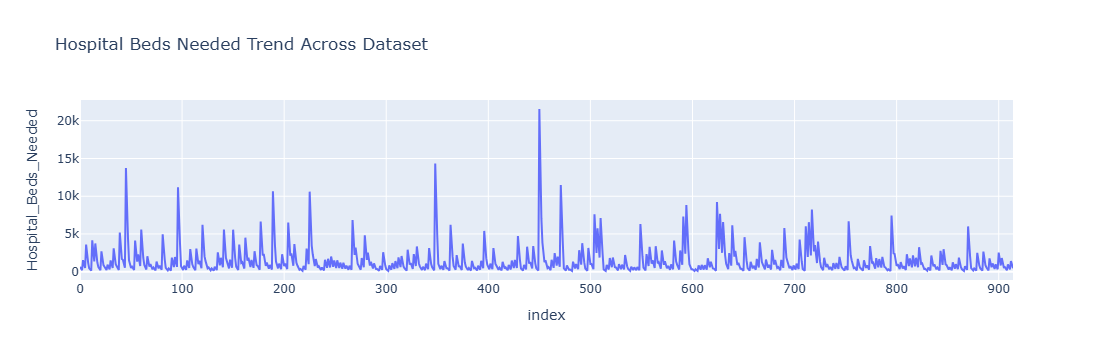

In [68]:
fig = px.line(df,
              x=df.index,
              y='Hospital_Beds_Needed',
              title='Hospital Beds Needed Trend Across Dataset')

fig.show()

# ICU Beds Needed Trend Across Dataset

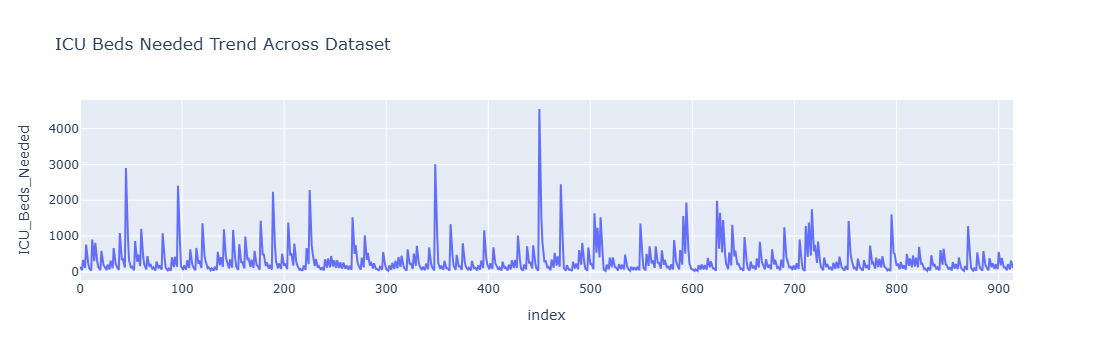

In [69]:
fig = px.line(df,
              x=df.index,
              y='ICU_Beds_Needed',
              title='ICU Beds Needed Trend Across Dataset')

fig.show()

# Hospital vs ICU Occupancy Rate Comparison

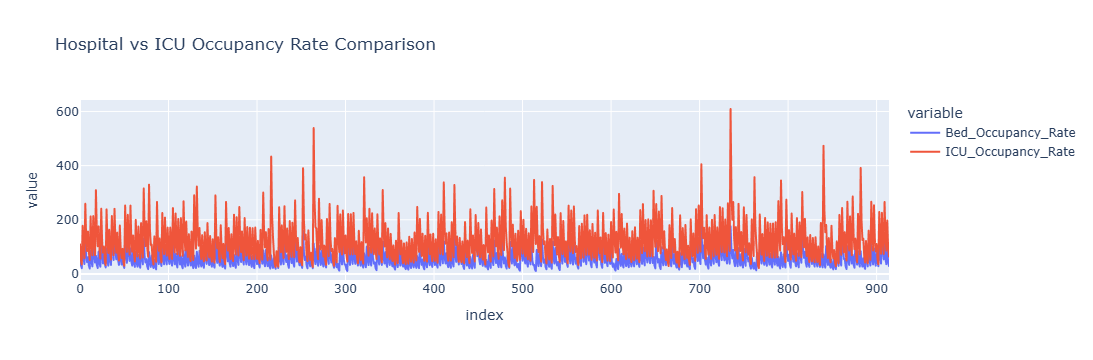

In [70]:
fig = px.line(df,
              x=df.index,
              y=['Bed_Occupancy_Rate','ICU_Occupancy_Rate'],
              title='Hospital vs ICU Occupancy Rate Comparison')

fig.show()

# Average Hospital Beds Needed by Time Period

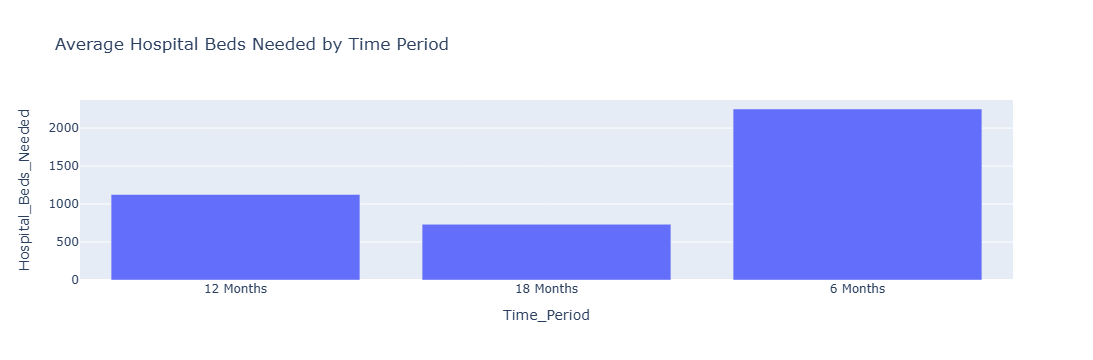

In [71]:
df_avg = df.groupby('Time_Period')['Hospital_Beds_Needed'].mean().reset_index()

fig = px.bar(df_avg,
             x='Time_Period',
             y='Hospital_Beds_Needed',
             title="Average Hospital Beds Needed by Time Period")

fig.show()

# Average ICU Occupancy Rate by Time Period

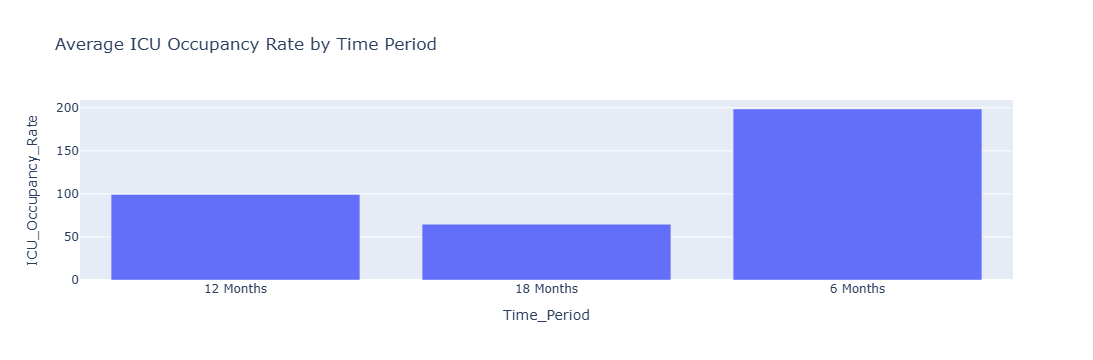

In [72]:
df_avg = df.groupby('Time_Period')['ICU_Occupancy_Rate'].mean().reset_index()

fig = px.bar(df_avg,
             x='Time_Period',
             y='ICU_Occupancy_Rate',
             title="Average ICU Occupancy Rate by Time Period")

fig.show()

# ICU Beds Needed vs Hospital Beds Needed

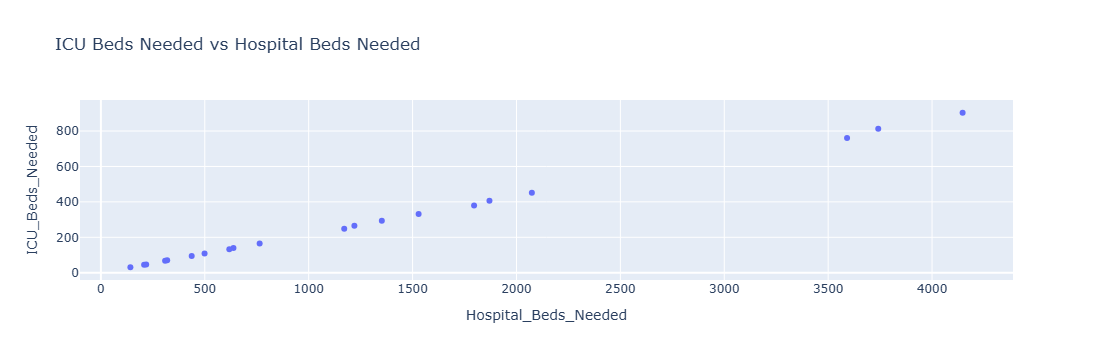

In [73]:
fig = px.scatter(df.head(20),
                 x='Hospital_Beds_Needed',
                 y='ICU_Beds_Needed',
                 title='ICU Beds Needed vs Hospital Beds Needed')

fig.show()

# Hospital Beds Needed Trend

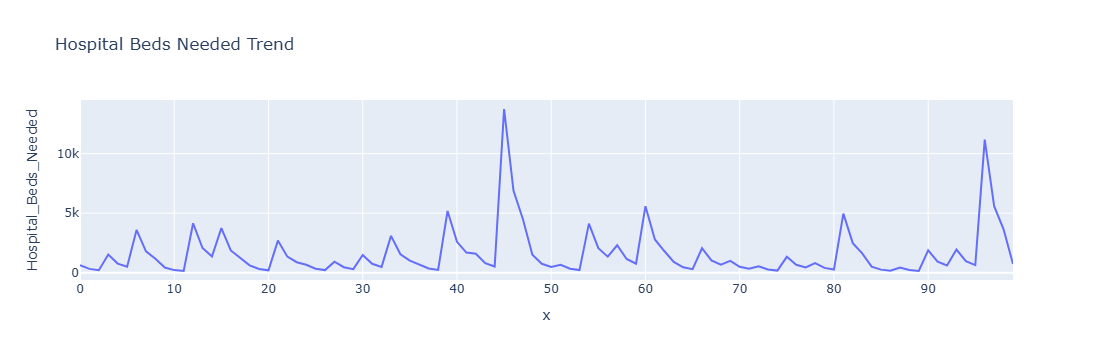

In [74]:
import plotly.express as px

fig = px.line(df.head(100),
              x=df.head(100).index,
              y='Hospital_Beds_Needed',
              title='Hospital Beds Needed Trend')

fig.show()

# Dataset Distribution by Time Period 

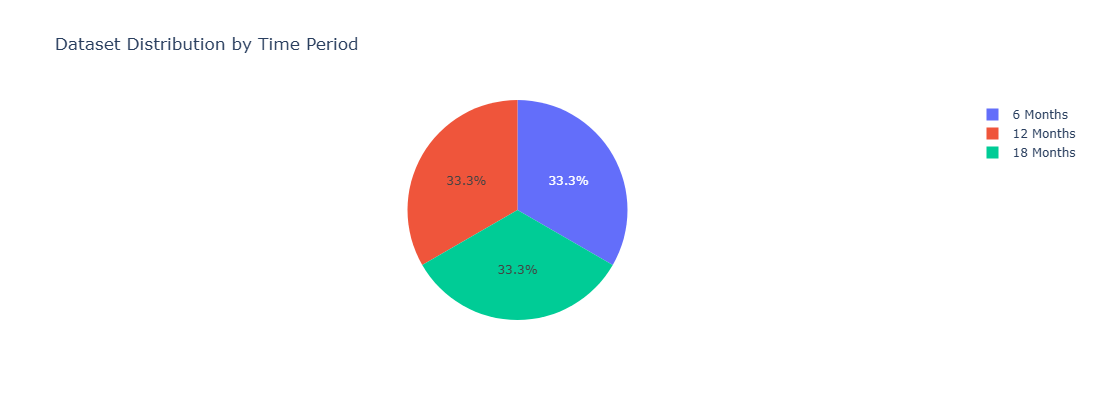

In [75]:
df_pie = df['Time_Period'].value_counts().reset_index()
df_pie.columns = ['Time_Period', 'count']

fig = px.pie(df_pie,
             names='Time_Period',
             values='count',
             title='Dataset Distribution by Time Period',
             width=400,
             height=400)

fig.show()

# Hospital Beds Needed Distribution

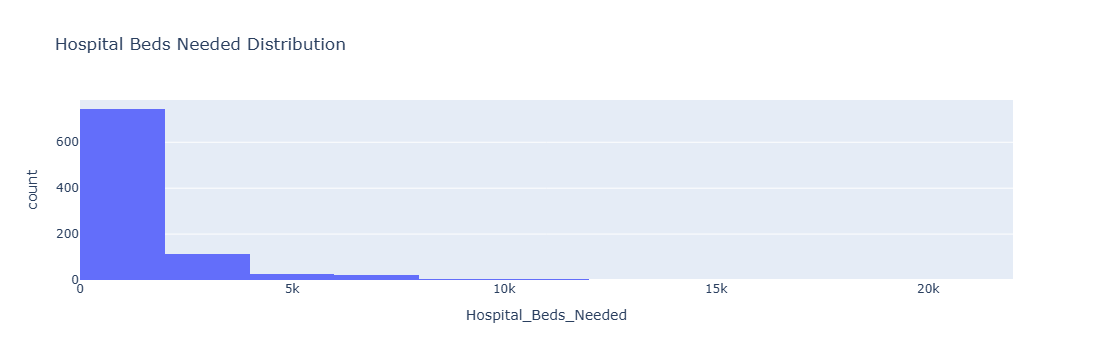

In [76]:
fig = px.histogram(df,
                   x='Hospital_Beds_Needed',
                   nbins=20,
                   title='Hospital Beds Needed Distribution')

fig.show()

# Hospital Beds Needed Distribution by Time Period

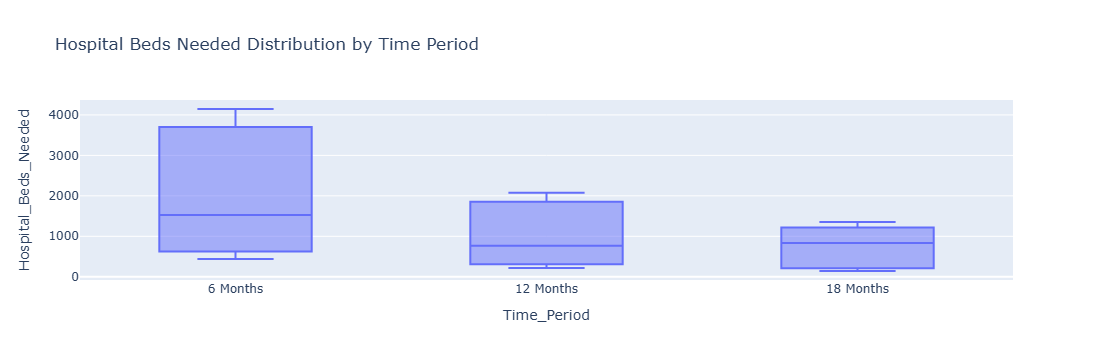

In [77]:
fig = px.box(df.head(20),
             x='Time_Period',
             y='Hospital_Beds_Needed',
             title="Hospital Beds Needed Distribution by Time Period")

fig.show()

# 3D Plot: Hospital Beds Needed vs ICU Beds Needed vs Bed Occupancy

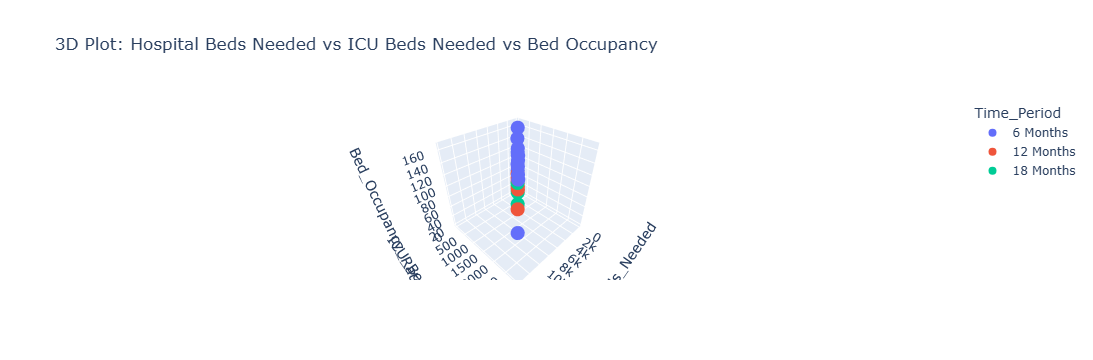

In [78]:
fig = px.scatter_3d(df.head(50),
                    x='Hospital_Beds_Needed',
                    y='ICU_Beds_Needed',
                    z='Bed_Occupancy_Rate',
                    color='Time_Period',
                    title='3D Plot: Hospital Beds Needed vs ICU Beds Needed vs Bed Occupancy')

fig.show()

# 3D Hospital Demand Analysis

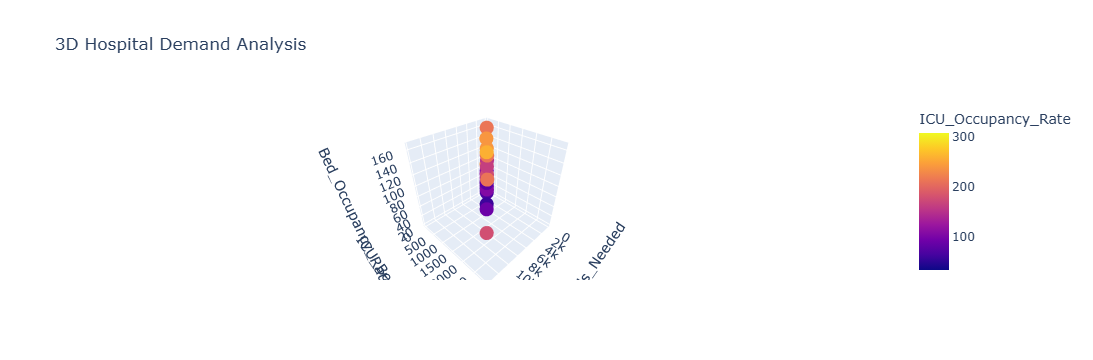

In [79]:
fig = px.scatter_3d(df.head(50),
                    x='Hospital_Beds_Needed',
                    y='ICU_Beds_Needed',
                    z='Bed_Occupancy_Rate',
                    color='ICU_Occupancy_Rate',
                    title='3D Hospital Demand Analysis')

fig.show()

# Hospital Beds Demand Over Time by Region

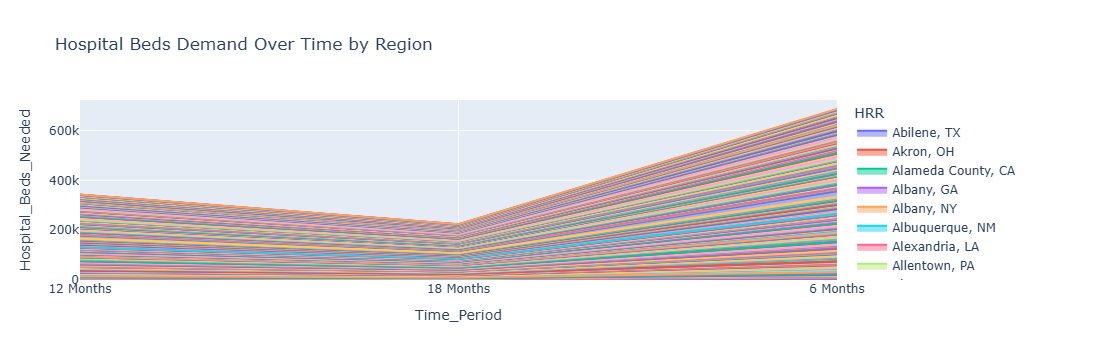

In [80]:
df_area = df.groupby(["Time_Period","HRR"])["Hospital_Beds_Needed"].sum().reset_index()

fig = px.area(
    df_area,
    x="Time_Period",
    y="Hospital_Beds_Needed",
    color="HRR",
    title="Hospital Beds Demand Over Time by Region"
)

fig.show()

# Hospital Beds Demand Distribution by Region and Time Period

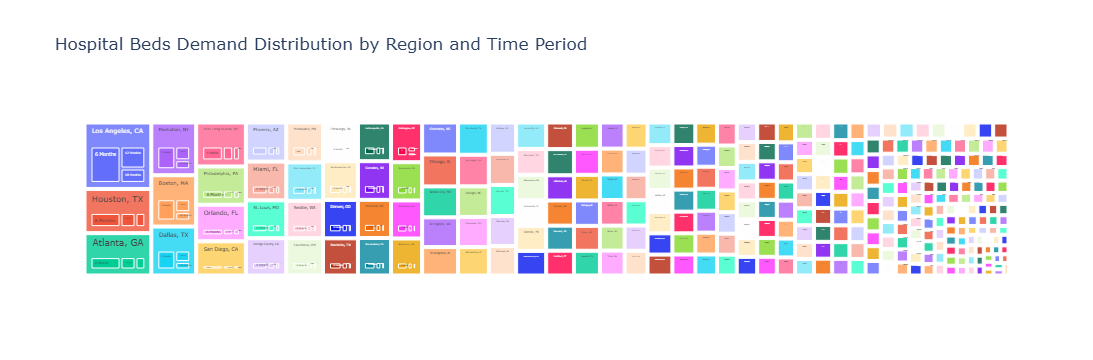

In [81]:
tree_data = df.groupby(["HRR", "Time_Period"], as_index=False)["Hospital_Beds_Needed"].sum()

fig = px.treemap(
    tree_data,
    path=["HRR", "Time_Period"],
    values="Hospital_Beds_Needed",
    title="Hospital Beds Demand Distribution by Region and Time Period"
)

fig.show()

# Hierarchical Sunburst of Hospital Beds Demand by Region and Time Period

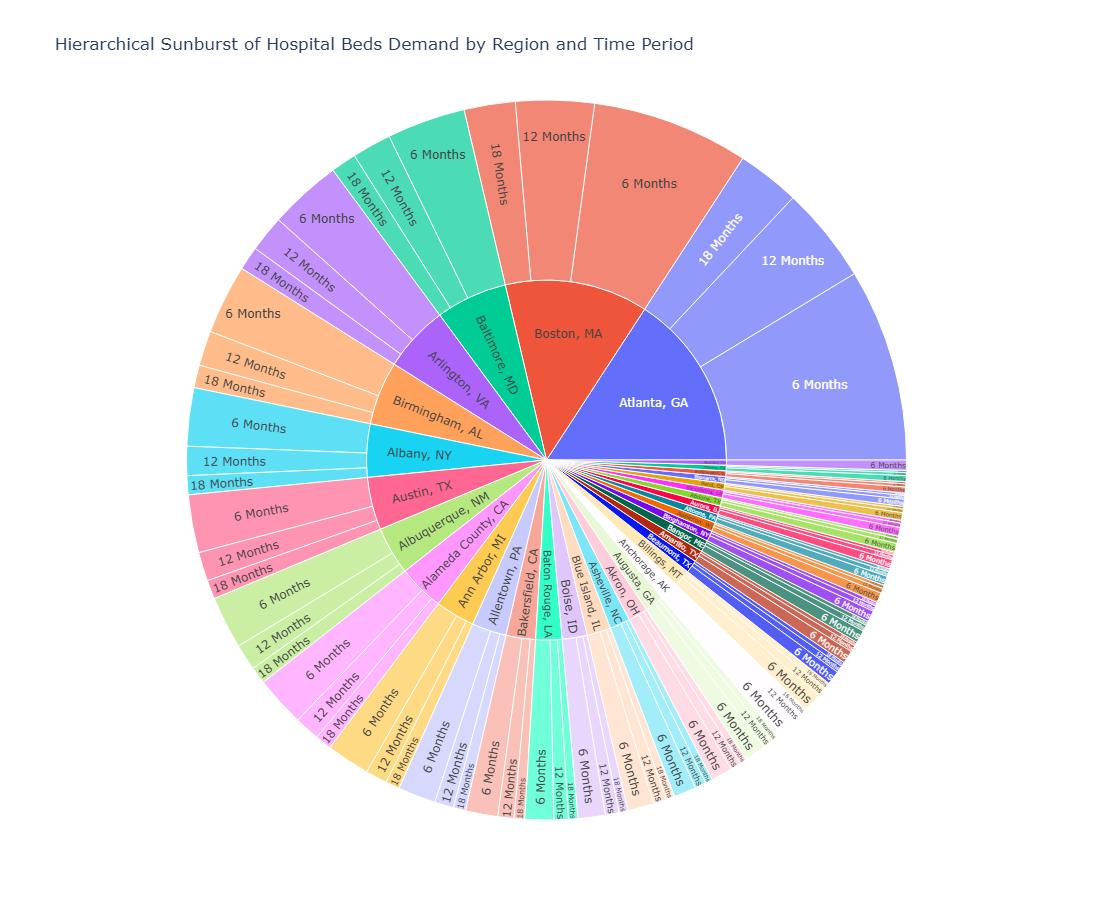

In [54]:
fig = px.sunburst(
    df.head(100),
    path=["HRR", "Time_Period"],
    values="Hospital_Beds_Needed",
    title="Hierarchical Sunburst of Hospital Beds Demand by Region and Time Period"
)

fig.update_layout(
    width=900,
    height=900
)

fig.show()

# Animated Hospital Beds Demand by Region Over Time

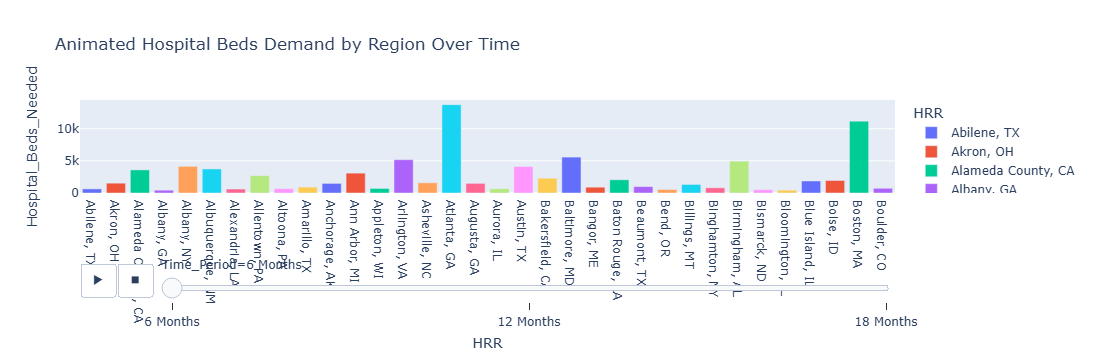

In [55]:
fig = px.bar(
    df.head(100),
    x="HRR",
    y="Hospital_Beds_Needed",
    color="HRR",
    animation_frame="Time_Period",
    title="Animated Hospital Beds Demand by Region Over Time"
)

fig.show()

# Hospital Resource Analytics Dashboard

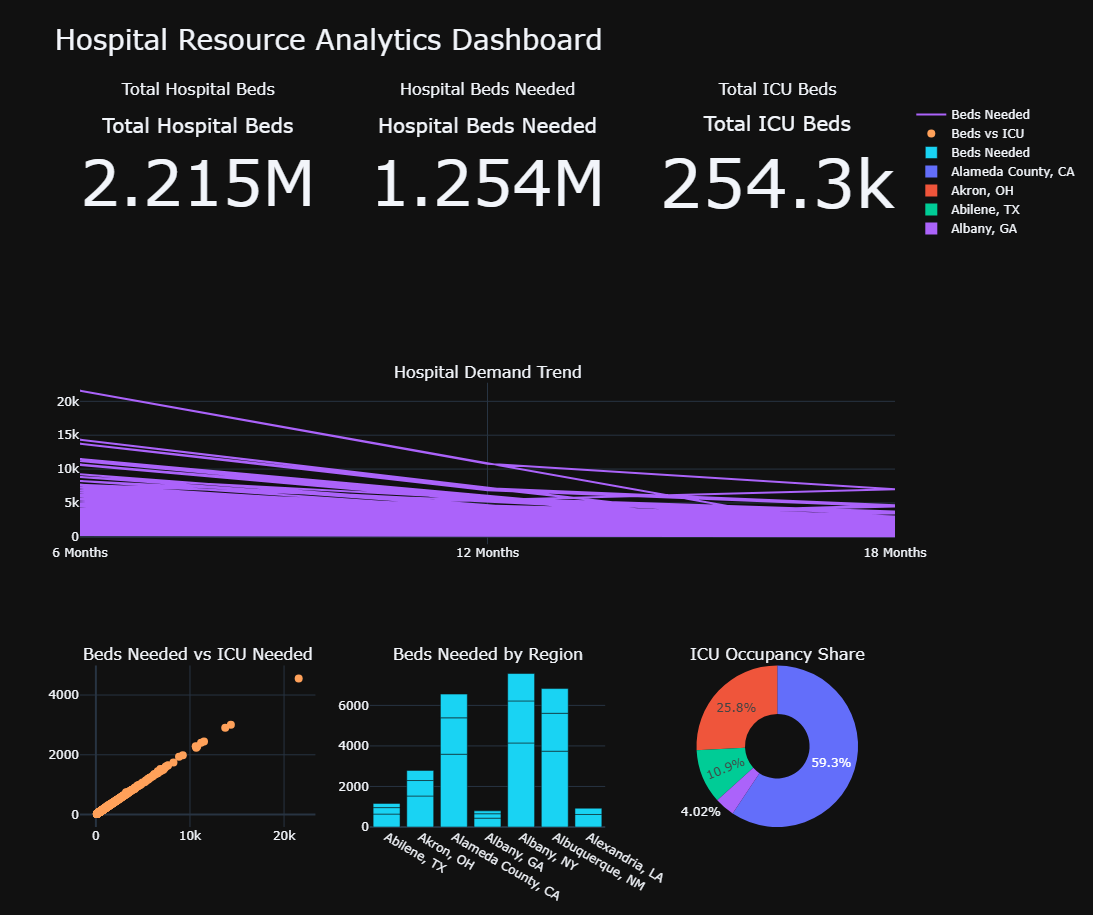

In [56]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

total_beds = df["Total_Hospital_Beds"].sum()
beds_needed = df["Hospital_Beds_Needed"].sum()
total_icu = df["Total_ICU_Beds"].sum()
avg_bed_occupancy = df["Bed_Occupancy_Rate"].mean()

fig = make_subplots(
    rows=3, cols=3,
    specs=[
        [{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}],
        [{"colspan":3,"type":"xy"},None,None],
        [{"type":"xy"},{"type":"xy"},{"type":"domain"}]
    ],
    subplot_titles=(
        "Total Hospital Beds",
        "Hospital Beds Needed",
        "Total ICU Beds",
        "Hospital Demand Trend",
        "Beds Needed vs ICU Needed",
        "Beds Needed by Region",
        "ICU Occupancy Share"
    )
)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_beds,
    title={"text":"Total Hospital Beds"}
),row=1,col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=beds_needed,
    title={"text":"Hospital Beds Needed"}
),row=1,col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_icu,
    title={"text":"Total ICU Beds"}
),row=1,col=3)

fig.add_trace(go.Scatter(
    x=df["Time_Period"],
    y=df["Hospital_Beds_Needed"],
    mode="lines",
    name="Beds Needed"
),row=2,col=1)

fig.add_trace(go.Scatter(
    x=df["Hospital_Beds_Needed"],
    y=df["ICU_Beds_Needed"],
    mode="markers",
    marker=dict(size=8),
    name="Beds vs ICU"
),row=3,col=1)

fig.add_trace(go.Bar(
    x=df["HRR"].head(20),
    y=df["Hospital_Beds_Needed"].head(20),
    name="Beds Needed"
),row=3,col=2)

fig.add_trace(go.Pie(
    labels=df["HRR"].head(10),
    values=df["ICU_Beds_Needed"].head(10),
    hole=0.4
),row=3,col=3)

fig.update_layout(
    height=900,
    width=1400,
    title="Hospital Resource Analytics Dashboard",
    template="plotly_dark",
    title_font_size=28
)

fig.show()

# Conclusion
# 1. Overview of the Study

In this study, hospital capacity data was analyzed to understand how healthcare resources are being used in different regions. The dataset contains information about hospital beds, ICU beds, available beds, beds required for patients, and occupancy rates. The data is also divided into different time periods such as 6 months, 12 months, and 18 months. The main aim of this study was to examine hospital bed utilization, identify demand patterns, and understand whether hospitals will have enough capacity in the future.

# 2. Data Analysis

To understand the dataset better, several exploratory data analysis (EDA) techniques were used. Different types of visualizations such as line charts, bar charts, histograms, scatter plots, box plots, pie charts, treemaps, sunburst charts, and 3D plots were created. These visualizations helped to observe patterns, relationships, and distributions in the data. The dashboard created using Plotly also provided an interactive way to view important information such as hospital bed demand, ICU demand, and occupancy rates. By examining the first 100 rows of the dataset, it was possible to quickly understand the structure of the data and how different variables are related.

# 3. Hospital Bed Utilization

The analysis of hospital bed usage shows that many regions have a high bed occupancy rate. In some regions, the number of hospital beds needed is very close to the total number of beds available. This means hospitals may face difficulties in managing patient demand if the number of patients increases. The trend analysis also indicates that bed requirements may increase over time, which could create additional pressure on hospital infrastructure. Monitoring bed utilization is important for hospitals to ensure that they can provide timely care to patients.

# 4. Healthcare Capacity Insights

The study provides useful insights about healthcare capacity and resource distribution. It shows that hospital resources are not evenly distributed across all regions. Some regions have sufficient beds available, while others may experience shortages, especially in ICU beds. ICU beds are critical for treating serious and life-threatening conditions, so any shortage can impact patient care. The comparison between available beds and required beds helps identify areas where healthcare infrastructure may need improvement.

# 5. Final Outcome

Overall, the analysis demonstrates the importance of using data to support healthcare planning and decision-making. By studying hospital bed demand and occupancy rates, healthcare authorities can better understand future challenges. The visualizations and dashboard created in this project help present the data in an easy and understandable way. These insights can help hospitals and healthcare planners improve resource management, prepare for increased patient demand, and ensure better healthcare services for the population.